In [4]:
import numpy as np
b = np.arange(6) + 10
b[4] = 9
print(b)
np.argmin(b)  # Only the first occurrence is returned.


[10 11 12 13  9 15]


4

In [7]:
import numpy as np
import sklearn.datasets
import sklearn.ensemble
import sklearn.model_selection


X, y = sklearn.datasets.load_digits(return_X_y=True)
rs = np.random.RandomState(42)
indices = np.arange(X.shape[0])
rs.shuffle(indices)
indices = indices[:150]
X = X[indices]
y = y[indices]
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X, y, random_state=16,
)
classifier = sklearn.ensemble.GradientBoostingClassifier(
    warm_start=False, n_estimators=1, random_state=1,
)
classifier.fit(X_train, y_train)
for i in range(99):
    classifier.n_estimators += 1
    classifier.fit(X_train, y_train)
print(classifier.score(X_test, y_test))

classifier = sklearn.ensemble.GradientBoostingClassifier(
    n_estimators=100, random_state=1,
)
classifier.fit(X_train, y_train)
print(classifier.score(X_test, y_test))

0.631578947368421
0.631578947368421


>lr 0.866 (0.029)
>knn 0.931 (0.025)
>cart 0.827 (0.043)
>svm 0.957 (0.020)
>bayes 0.833 (0.031)
>stacking 0.964 (0.019)


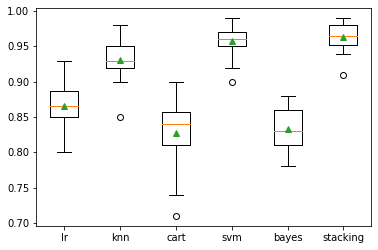

In [1]:

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
# compare ensemble to each baseline classifier
from numpy import mean
from numpy import std
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import StackingClassifier
from matplotlib import pyplot
 
# get the dataset
def get_dataset():
	X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, random_state=1)
	return X, y
 
# get a stacking ensemble of models
def get_stacking():
	# define the base models
	level0 = list()
	level0.append(('lr', LogisticRegression()))
	level0.append(('knn', KNeighborsClassifier()))
	level0.append(('cart', DecisionTreeClassifier()))
	level0.append(('svm', SVC()))
	level0.append(('bayes', GaussianNB()))
	# define meta learner model
	level1 = LogisticRegression()
	# define the stacking ensemble
	model = StackingClassifier(estimators=level0, final_estimator=level1, cv=5)
	return model
 
# get a list of models to evaluate
def get_models():
	models = dict()
	models['lr'] = LogisticRegression()
	models['knn'] = KNeighborsClassifier()
	models['cart'] = DecisionTreeClassifier()
	models['svm'] = SVC()
	models['bayes'] = GaussianNB()
	models['stacking'] = get_stacking()
	return models
 
# evaluate a give model using cross-validation
def evaluate_model(model, X, y):
	cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
	scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
	return scores
 
# define dataset
X, y = get_dataset()
# get the models to evaluate
models = get_models()
# evaluate the models and store results
results, names = list(), list()
for name, model in models.items():
	scores = evaluate_model(model, X, y)
	results.append(scores)
	names.append(name)
	print('>%s %.3f (%.3f)' % (name, mean(scores), std(scores)))
# plot model performance for comparison
pyplot.boxplot(results, labels=names, showmeans=True)
pyplot.show()